### Importing

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

### Loading Data

In [ ]:
dataframe = pd.read_csv(filepath_or_buffer = "Spiral.csv")
dataframe.head()

,31.95,7.95,3
0,31.15,7.30,3
1,30.45,6.65,3
2,29.70,6.00,3
3,28.90,5.55,3
4,28.05,5.00,3


### EDA

In [60]:
dataframe.shape

(311, 3)

In [61]:
dataframe.columns

Index(['31.95', '7.95', '3'], dtype='object')

In [62]:
dataframe.duplicated().sum()

np.int64(0)

In [63]:
dataframe.isnull().sum()

31.95    0
7.95     0
3        0
dtype: int64

In [64]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   31.95   311 non-null    float64
 1   7.95    311 non-null    float64
 2   3       311 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 7.4 KB


In [65]:
dataframe.describe().T

,count,mean,std,min,25%,50%,75%,max
31.95,311.0,18.364630,7.270992,3.0,12.875,18.20,23.275,31.65
7.95,311.0,16.371704,6.861701,2.9,11.375,16.05,21.425,31.65
3,311.0,2.012862,0.815077,1.0,1.000,2.00,3.000,3.00


In [66]:
data = dataframe.iloc[: , [0 , 1]].values

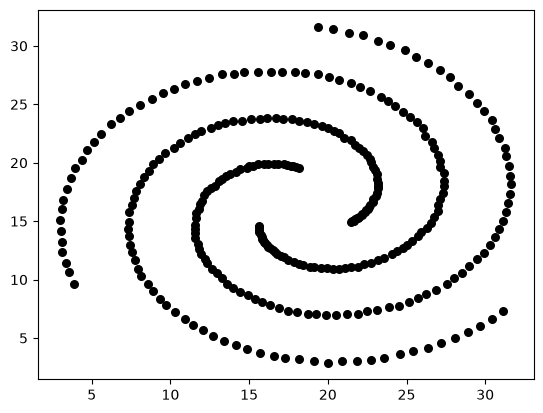

In [70]:
plt.scatter(data[: , 0] , data[: , 1] , s = 30 , color = "black")
plt.show()

### Elbow Method(KMeans)

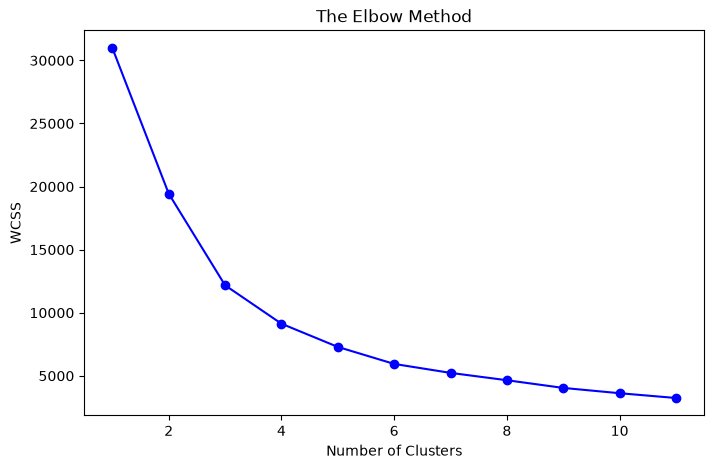

In [72]:
wcss = []

for i in range(1 , 12):
    model = KMeans(n_clusters = i , init = "k-means++" , n_init = 10 , max_iter = 300)
    model.fit(data)
    wcss.append(model.inertia_)

plt.figure(figsize = (8 , 5))
plt.plot(range(1 , 12) , wcss , "bo-")
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Train Model & Visualize Clusters

In [80]:
final_model = DBSCAN(eps = 3 , min_samples = 5)
result = final_model.fit_predict(data)

In [84]:
dataframe["result"] = result

In [85]:
dataframe["result"].value_counts()

result
0    105
2    105
1    101
Name: count, dtype: int64

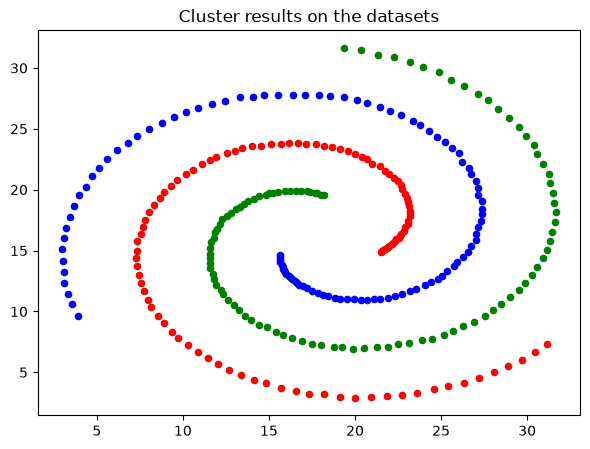

In [87]:
plt.figure(figsize = (7 , 5))
plt.scatter(data[result == 0 , 0] , data[result == 0 , 1] , s = 20 , c = "red")
plt.scatter(data[result == 1 , 0] , data[result == 1 , 1] , s = 20 , c = "green")
plt.scatter(data[result == 2 , 0] , data[result == 2 , 1] , s = 20 , c = "blue")

plt.title("Cluster results on the datasets")
plt.show()